# Butane Dihedral Analysis (Week 4)

This notebook analyzes butane C-C-C-C torsional angles from a two-column text file (frame, dihedral angle in degrees), wraps angles into [0, 360], and creates the required plots and binned counts.



## Reference Run Metadata

- Temperature: 400 K

- MD steps: 1,000,000

- Source config: week3/butane.namd

- Purpose: baseline run for comparison with new runs



## Comparison Log (fill as you add runs)

- Run A (reference): 400 K, 1,000,000 steps, prefix `week4_ref_400K_1e6`

- Run B: ...

- Run C: ...

In [1]:
# GitHub Copilot (GPT-5.3-Codex)
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

In [4]:
# Inputs

input_path = Path("multiplot.dat")

prefix = "week4_ref_400K_1e6"

bin_size = 10.0  # degrees

timestep_fs = 1.0



# Run metadata for one-by-one comparisons

temperature_K = 400

n_steps = 1_000_000



if not input_path.exists():

    raise FileNotFoundError(f"Input file not found: {input_path}")

if bin_size <= 0:

    raise ValueError("bin_size must be positive")

if timestep_fs <= 0:

    raise ValueError("timestep_fs must be positive")



data = np.loadtxt(input_path, usecols=(0, 1))

if data.ndim == 1:

    data = np.expand_dims(data, axis=0)



frame = data[:, 0]

angle_deg_raw = data[:, 1]

angle_deg_wrapped = np.mod(angle_deg_raw, 360.0)

angle_rad = np.deg2rad(angle_deg_wrapped)

time_ps = frame * timestep_fs / 1000.0



print(f"Loaded {len(frame)} frames from {input_path}")

print(f"Run metadata: T={temperature_K} K, steps={n_steps:,}")

Loaded 1001 frames from multiplot.dat
Run metadata: T=400 K, steps=1,000,000


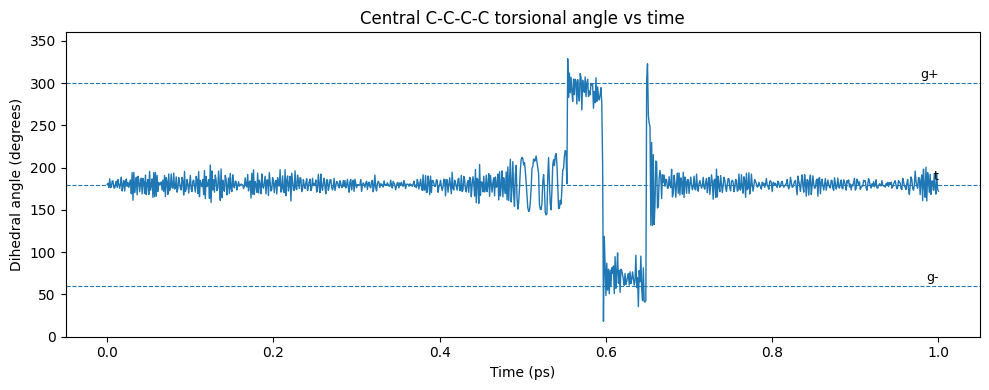

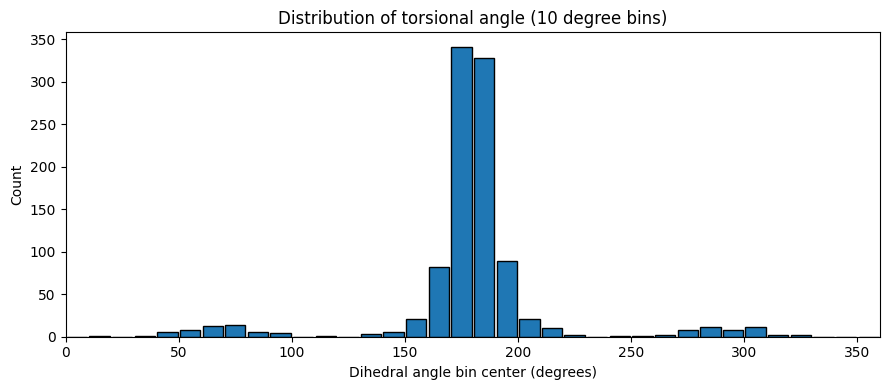

Trajectory plot: week4_ref_400K_1e6_trajectory.png
Histogram plot: week4_ref_400K_1e6_histogram.png
Processed angle data: week4_ref_400K_1e6_angles.csv
Histogram counts: week4_ref_400K_1e6_histogram_counts.txt


In [5]:
# Plot 1: trajectory (angle vs time)
trajectory_png = Path(f"{prefix}_trajectory.png")

plt.figure(figsize=(10, 4))
plt.plot(time_ps, angle_deg_wrapped, linewidth=1)
plt.xlabel("Time (ps)")
plt.ylabel("Dihedral angle (degrees)")
plt.title("Central C-C-C-C torsional angle vs time")
plt.ylim(0, 360)

for state_angle, label in ((60, "g-"), (180, "t"), (300, "g+")):
    plt.axhline(state_angle, linestyle="--", linewidth=0.8)
    plt.text(time_ps[-1], state_angle + 2, label, ha="right", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(trajectory_png, dpi=200)
plt.show()

# Plot 2: histogram (count distribution)
histogram_png = Path(f"{prefix}_histogram.png")
bins = np.arange(0, 360 + bin_size, bin_size)
counts, edges = np.histogram(angle_deg_wrapped, bins=bins)
centers = 0.5 * (edges[:-1] + edges[1:])

plt.figure(figsize=(9, 4))
plt.bar(centers, counts, width=bin_size * 0.9, edgecolor="black", align="center")
plt.xlabel("Dihedral angle bin center (degrees)")
plt.ylabel("Count")
plt.title(f"Distribution of torsional angle ({bin_size:g} degree bins)")
plt.xlim(0, 360)
plt.tight_layout()
plt.savefig(histogram_png, dpi=200)
plt.show()

# Save processed tables
angles_csv = Path(f"{prefix}_angles.csv")
hist_txt = Path(f"{prefix}_histogram_counts.txt")

angle_matrix = np.column_stack((frame, time_ps, angle_deg_raw, angle_deg_wrapped, angle_rad))
np.savetxt(
    angles_csv,
    angle_matrix,
    delimiter=",",
    header="frame,time_ps,angle_deg_raw,angle_deg_wrapped,angle_rad",
    comments="",
)

hist_data = np.column_stack((centers, counts))
np.savetxt(hist_txt, hist_data, header="bin_center_deg count", fmt=["%.3f", "%d"])

print(f"Trajectory plot: {trajectory_png}")
print(f"Histogram plot: {histogram_png}")
print(f"Processed angle data: {angles_csv}")
print(f"Histogram counts: {hist_txt}")

In [6]:
import MDAnalysis as mda

from MDAnalysis.analysis.dihedrals import Dihedral



# Load 800K trajectory

psf_path = "../week3/butane.psf"

dcd_800K = "../week3/i_guess_800K.dcd"



u = mda.Universe(psf_path, dcd_800K)



# C1-C2-C3-C4 dihedral: PSF atom indices 4,7,10,14 → 0-based: 3,6,9,13

ag = u.atoms[[3, 6, 9, 13]]

dih = Dihedral([ag]).run()



angle_800K_raw = dih.results.angles.flatten()          # degrees, range [-180, 180]

angle_800K_wrapped = np.mod(angle_800K_raw, 360.0)    # shift to [0, 360]

frame_800K = np.arange(len(angle_800K_wrapped))

time_800K_ps = frame_800K * timestep_fs / 1000.0



print(f"800K run: {len(angle_800K_wrapped)} frames extracted from {dcd_800K}")

/Users/mchalil/Documents/MAT306/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


800K run: 1001 frames extracted from ../week3/i_guess_800K.dcd


/Users/mchalil/Documents/MAT306/.venv/lib/python3.11/site-packages/MDAnalysis/coordinates/DCD.py:171: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


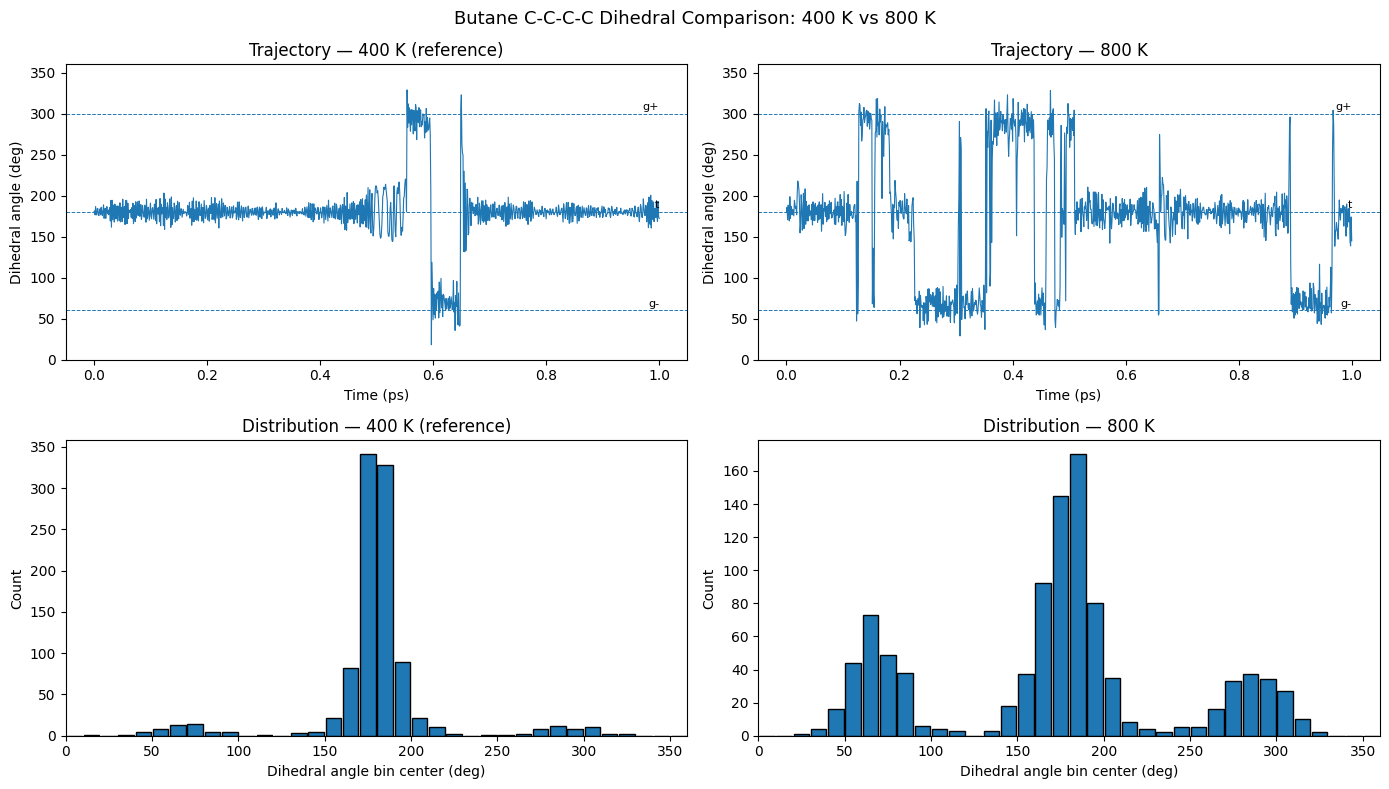

Comparison plot saved: week4_comparison_400K_vs_800K.png


In [7]:
# ---- Side-by-side comparison plots ----



fig, axes = plt.subplots(2, 2, figsize=(14, 8))

fig.suptitle("Butane C-C-C-C Dihedral Comparison: 400 K vs 800 K", fontsize=13)



state_lines = [(60, "g-"), (180, "t"), (300, "g+")]



# --- Trajectory plots ---

for ax, t_arr, a_arr, label in [

    (axes[0, 0], time_ps,      angle_deg_wrapped, "400 K (reference)"),

    (axes[0, 1], time_800K_ps, angle_800K_wrapped, "800 K"),

]:

    ax.plot(t_arr, a_arr, linewidth=0.8)

    ax.set_xlabel("Time (ps)")

    ax.set_ylabel("Dihedral angle (deg)")

    ax.set_title(f"Trajectory — {label}")

    ax.set_ylim(0, 360)

    for s, sl in state_lines:

        ax.axhline(s, linestyle="--", linewidth=0.7)

        ax.text(t_arr[-1], s + 2, sl, ha="right", va="bottom", fontsize=8)



# --- Histogram plots ---

bin_size_cmp = 10.0

bins_cmp = np.arange(0, 360 + bin_size_cmp, bin_size_cmp)

centers_cmp = 0.5 * (bins_cmp[:-1] + bins_cmp[1:])



counts_400K, _ = np.histogram(angle_deg_wrapped,  bins=bins_cmp)

counts_800K, _ = np.histogram(angle_800K_wrapped, bins=bins_cmp)



for ax, cnts, label in [

    (axes[1, 0], counts_400K, "400 K (reference)"),

    (axes[1, 1], counts_800K, "800 K"),

]:

    ax.bar(centers_cmp, cnts, width=bin_size_cmp * 0.9, edgecolor="black", align="center")

    ax.set_xlabel("Dihedral angle bin center (deg)")

    ax.set_ylabel("Count")

    ax.set_title(f"Distribution — {label}")

    ax.set_xlim(0, 360)



plt.tight_layout()

comparison_png = Path("week4_comparison_400K_vs_800K.png")

plt.savefig(comparison_png, dpi=200)

plt.show()

print(f"Comparison plot saved: {comparison_png}")

## Free-Energy Profiles
Using the Boltzmann inversion: $\Delta G(\phi) = -RT \ln P(\phi)$, shifted so the minimum is zero.

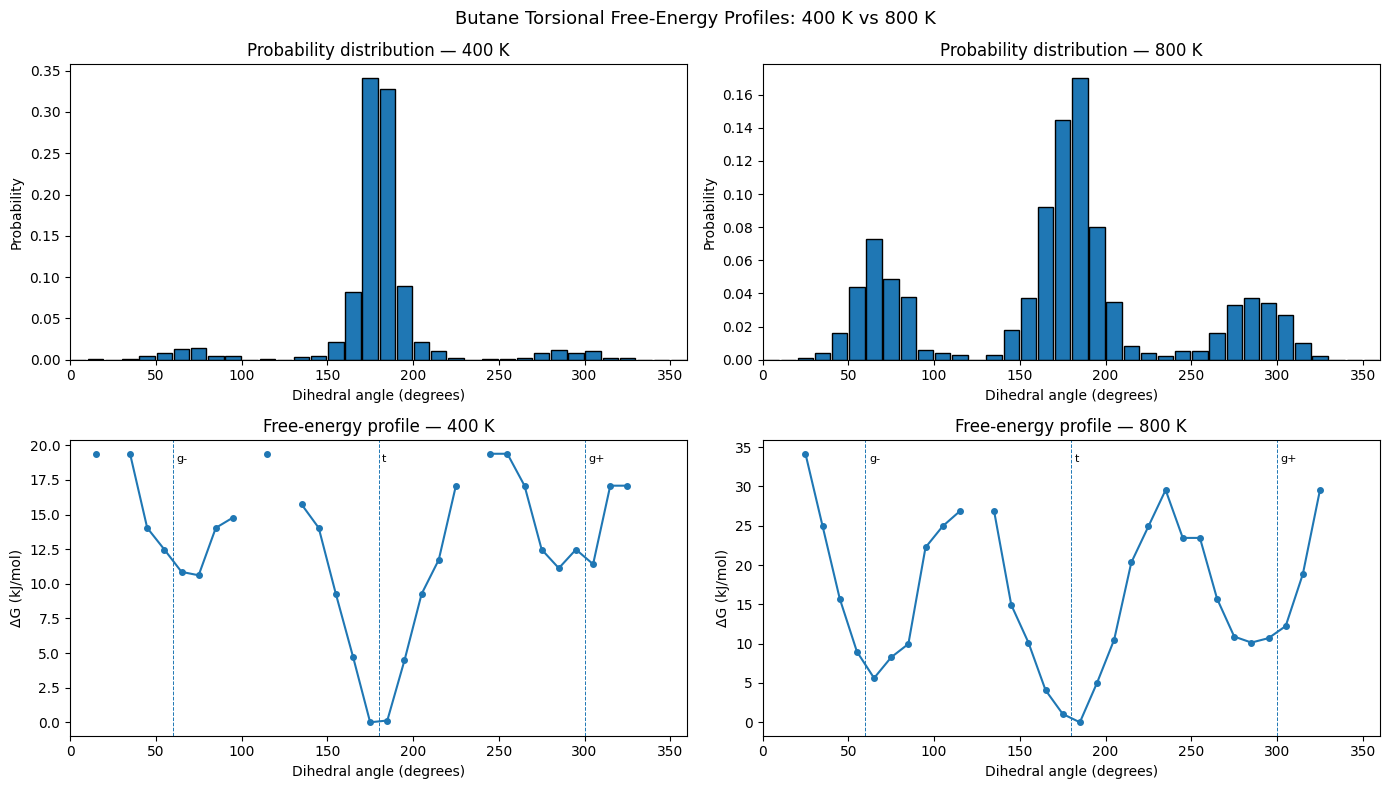

Energy profile plot saved: week4_energy_profiles_400K_vs_800K.png


In [8]:
R = 8.314e-3  # kJ mol⁻¹ K⁻¹

def free_energy_profile(counts, temperature_K):
    """Boltzmann inversion: ΔG = -RT ln(P), shifted to zero at the minimum."""
    P = counts / counts.sum()
    G = np.full_like(P, np.nan, dtype=float)
    mask = P > 0
    G[mask] = -R * temperature_K * np.log(P[mask])
    G -= np.nanmin(G)
    return P, G

bin_size_e = 10.0
bins_e = np.arange(0, 360 + bin_size_e, bin_size_e)
centers_e = 0.5 * (bins_e[:-1] + bins_e[1:])

counts_e_400K, _ = np.histogram(angle_deg_wrapped,  bins=bins_e)
counts_e_800K, _ = np.histogram(angle_800K_wrapped, bins=bins_e)

P_400K, G_400K = free_energy_profile(counts_e_400K, temperature_K=400)
P_800K, G_800K = free_energy_profile(counts_e_800K, temperature_K=800)

# ---- 2×2: probability + energy for each run ----
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Butane Torsional Free-Energy Profiles: 400 K vs 800 K", fontsize=13)

for col, (P, G, label) in enumerate([(P_400K, G_400K, "400 K"), (P_800K, G_800K, "800 K")]):
    # Probability
    axes[0, col].bar(centers_e, P, width=bin_size_e * 0.9, edgecolor="black", align="center")
    axes[0, col].set_xlabel("Dihedral angle (degrees)")
    axes[0, col].set_ylabel("Probability")
    axes[0, col].set_title(f"Probability distribution — {label}")
    axes[0, col].set_xlim(0, 360)

    # Free energy
    axes[1, col].plot(centers_e, G, marker="o", markersize=4, linewidth=1.5)
    axes[1, col].set_xlabel("Dihedral angle (degrees)")
    axes[1, col].set_ylabel("ΔG (kJ/mol)")
    axes[1, col].set_title(f"Free-energy profile — {label}")
    axes[1, col].set_xlim(0, 360)
    for s, sl in [(60, "g-"), (180, "t"), (300, "g+")]:
        axes[1, col].axvline(s, linestyle="--", linewidth=0.7)
        axes[1, col].text(s + 2, axes[1, col].get_ylim()[1] * 0.95, sl, fontsize=8, va="top")

plt.tight_layout()
energy_png = Path("week4_energy_profiles_400K_vs_800K.png")
plt.savefig(energy_png, dpi=200)
plt.show()
print(f"Energy profile plot saved: {energy_png}")